<a href="https://colab.research.google.com/github/Mark1507/Kovychev_MLF/blob/main/Ex_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU, Flatten
from tensorflow.keras.optimizers import Adam


### 1.1 Generating dataset

In [65]:
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0,1,n_steps)

    series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
    series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
    series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
    return series[..., np.newaxis].astype(np.float32)

In [66]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [67]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [21]:
no_training_epochs = 5

### 1.3 Data examination

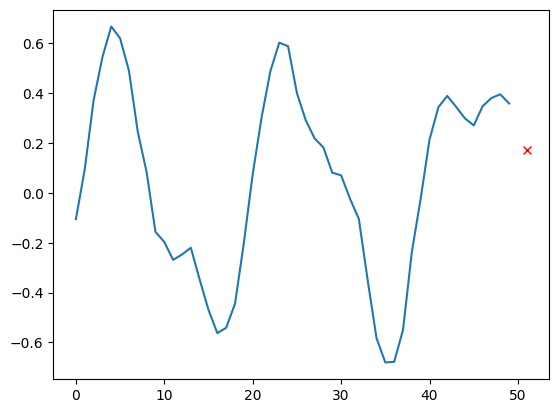

In [68]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [69]:
def plot_function(history):
    plt.figure()
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='validation_loss')
    plt.legend()
    plt.grid()
    plt.xlim([0, no_training_epochs-1])
    plt.xlabel('epochs')


In [70]:
model_lstm = Sequential()
model_lstm.add(LSTM(50, input_shape=[50, 1]))
model_lstm.add(Dense(1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [73]:
optimizer_lstm = Adam(0.001)
model_lstm.compile(loss='mean_squared_error', optimizer=optimizer_lstm, metrics=['mean_squared_error'])


Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0333 - mean_squared_error: 0.0333 - val_loss: 0.0123 - val_mean_squared_error: 0.0123
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0071 - mean_squared_error: 0.0071 - val_loss: 0.0038 - val_mean_squared_error: 0.0038
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0037 - mean_squared_error: 0.0037 - val_loss: 0.0033 - val_mean_squared_error: 0.0033
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0034 - mean_squared_error: 0.0034 - val_loss: 0.0032 - val_mean_squared_error: 0.0032
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0031 - mean_squared_error: 0.0031 - val_loss: 0.0031 - val_mean_squared_error: 0.0031


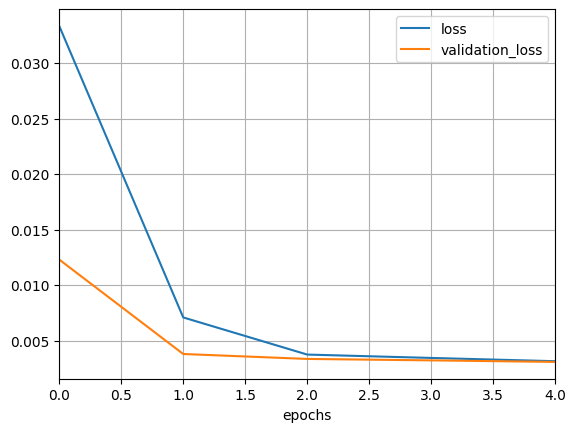

In [72]:
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=no_training_epochs,
    validation_data=[X_valid, y_valid]
)
plot_function(history_lstm)


In [74]:
score_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
print("LSTM Test loss:", score_lstm[0])
print("LSTM Test MSE:", score_lstm[1])


LSTM Test loss: 0.003266610438004136
LSTM Test MSE: 0.003266610438004136


In [76]:
model_gru = Sequential()
model_gru.add(GRU(50, input_shape=[50, 1]))
model_gru.add(Dense(1))


In [77]:
optimizer_gru = Adam(0.001)
model_gru.compile(loss='mean_squared_error', optimizer=optimizer_gru, metrics=['mean_squared_error'])


Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0315 - mean_squared_error: 0.0315 - val_loss: 0.0105 - val_mean_squared_error: 0.0105
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0064 - mean_squared_error: 0.0064 - val_loss: 0.0043 - val_mean_squared_error: 0.0043
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0043 - mean_squared_error: 0.0043 - val_loss: 0.0040 - val_mean_squared_error: 0.0040
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0041 - mean_squared_error: 0.0041 - val_loss: 0.0038 - val_mean_squared_error: 0.0038
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0039 - mean_squared_error: 0.0039 - val_loss: 0.0043 - val_mean_squared_error: 0.0043


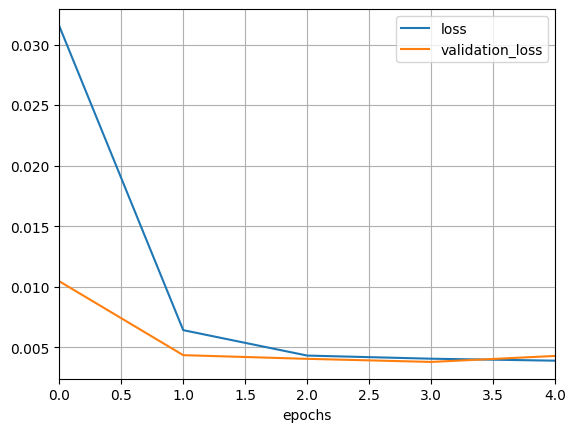

In [78]:
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=no_training_epochs,
    validation_data=[X_valid, y_valid]
)
plot_function(history_gru)


In [79]:
score_gru = model_gru.evaluate(X_test, y_test, verbose=0)
print("GRU Test loss:", score_gru[0])
print("GRU Test MSE:", score_gru[1])


GRU Test loss: 0.004371298477053642
GRU Test MSE: 0.004371298477053642


### 1.5 Simple RNN Model

In [80]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(50, input_shape=[50, 1]))
model_simple_rnn.add(Dense(1))

In [82]:
optimizer_simple_rnn = Adam(0.001)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0180 - mean_squared_error: 0.0180 - val_loss: 0.0048 - val_mean_squared_error: 0.0048
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0037 - val_mean_squared_error: 0.0037
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0034 - mean_squared_error: 0.0034 - val_loss: 0.0029 - val_mean_squared_error: 0.0029
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0031 - mean_squared_error: 0.0031 - val_loss: 0.0028 - val_mean_squared_error: 0.0028
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0029 - mean_squared_error: 0.0029 - val_loss: 0.0029 - val_mean_squared_error: 0.0029


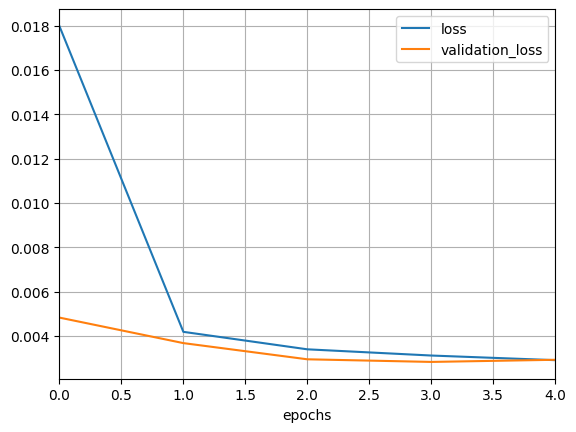

In [83]:
history_simple_rnn = model_simple_rnn.fit(
    X_train, y_train,
    epochs=no_training_epochs,
    validation_data=[X_valid, y_valid]
)
plot_function(history_simple_rnn)


In [84]:
score_simple = model_simple_rnn.evaluate(X_test, y_test, verbose=0)
print("Simple RNN Test loss:", score_simple[0])
print("Simple RNN Test MSE:", score_simple[1])


Simple RNN Test loss: 0.0031784854363650084
Simple RNN Test MSE: 0.0031784854363650084


### 1.5 Deep RNN Model

In [85]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [87]:
optimizer_deep_rnn = Adam(0.001)
model_deep_rnn.compile(loss='mean_squared_error',
                       optimizer=optimizer_deep_rnn,
                       metrics=['mean_squared_error'])

In [88]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0263 - mean_squared_error: 0.0263 - val_loss: 0.0078 - val_mean_squared_error: 0.0078
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0074 - mean_squared_error: 0.0074 - val_loss: 0.0050 - val_mean_squared_error: 0.0050
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0051 - mean_squared_error: 0.0051 - val_loss: 0.0049 - val_mean_squared_error: 0.0049
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0039 - val_mean_squared_error: 0.0039
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0039 - mean_squared_error: 0.0039 - val_loss: 0.0056 - val_mean_squared_error: 0.0056


In [93]:
score_deep = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print("Deep RNN Test loss:", score_deep[0])
print("Deep RNN Test MSE:", score_deep[1])

Deep RNN Test loss: 0.00537635013461113
Deep RNN Test MSE: 0.00537635013461113


## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU
from tensorflow.keras.optimizers import Adam



### 2.1 - Load dataset

In [99]:
(X_train_imdb, y_train_imdb), (X_test_imdb, y_test_imdb) = keras.datasets.imdb.load_data()


In [100]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3: word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
    id_to_word[id_] = token

single_sequence = " ".join([id_to_word[id_] for id_ in X_train_imdb[0]])
single_sequence


"<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and shou

In [101]:
max_length = 150
X_train_imdb = keras.preprocessing.sequence.pad_sequences(
    X_train_imdb, maxlen=max_length, padding='post', truncating='post'
)
X_test_imdb = keras.preprocessing.sequence.pad_sequences(
    X_test_imdb, maxlen=max_length, padding='post', truncating='post'
)


In [102]:
embed_size = 128
vocabulary_size = 10000


In [103]:
model_simple_imdb = keras.models.Sequential([
    Embedding(vocabulary_size, embed_size, input_shape=[None]),
    SimpleRNN(128),
    Dense(1, activation='sigmoid')
])

model_simple_imdb.compile(
    loss="binary_crossentropy",
    optimizer=Adam(0.001),
    metrics=["accuracy"]
)

history_simple_imdb = model_simple_imdb.fit(
    X_train_imdb, y_train_imdb,
    epochs=5,
    validation_split=0.2
)

score_simple_imdb = model_simple_imdb.evaluate(X_test_imdb, y_test_imdb, verbose=0)
print("SimpleRNN Test accuracy:", score_simple_imdb[1] * 100, "%")


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5027 - loss: 0.7014 - val_accuracy: 0.5062 - val_loss: 0.6948
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5270 - loss: 0.6923 - val_accuracy: 0.5126 - val_loss: 0.6944
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5745 - loss: 0.6706 - val_accuracy: 0.5216 - val_loss: 0.7005
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6223 - loss: 0.6249 - val_accuracy: 0.5578 - val_loss: 0.7116
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6916 - loss: 0.5565 - val_accuracy: 0.5624 - val_loss: 0.7283
SimpleRNN Test accuracy: 56.08000159263611 %


In [104]:
model_lstm_imdb = keras.models.Sequential([
    Embedding(vocabulary_size, embed_size, input_shape=[None]),
    LSTM(128, return_sequences=True),
    LSTM(128),
    Dense(1, activation='sigmoid')
])

model_lstm_imdb.compile(
    loss="binary_crossentropy",
    optimizer=Adam(0.001),
    metrics=["accuracy"]
)

history_lstm_imdb = model_lstm_imdb.fit(
    X_train_imdb, y_train_imdb,
    epochs=5,
    validation_split=0.2
)

score_lstm_imdb = model_lstm_imdb.evaluate(X_test_imdb, y_test_imdb, verbose=0)
print("LSTM Test accuracy:", score_lstm_imdb[1] * 100, "%")


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.5964 - loss: 0.6628 - val_accuracy: 0.6550 - val_loss: 0.6711
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5579 - loss: 0.6770 - val_accuracy: 0.5130 - val_loss: 0.6922
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6097 - loss: 0.6351 - val_accuracy: 0.8328 - val_loss: 0.4035
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8643 - loss: 0.3349 - val_accuracy: 0.8458 - val_loss: 0.3617
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9163 - loss: 0.2251 - val_accuracy: 0.8476 - val_loss: 0.3902
LSTM Test accuracy: 83.59599709510803 %


In [105]:
model_gru_imdb = keras.models.Sequential([
    Embedding(vocabulary_size, embed_size, input_shape=[None]),
    GRU(128, return_sequences=True),
    GRU(128),
    Dense(1, activation='sigmoid')
])

model_gru_imdb.compile(
    loss="binary_crossentropy",
    optimizer=Adam(0.001),
    metrics=["accuracy"]
)

history_gru_imdb = model_gru_imdb.fit(
    X_train_imdb, y_train_imdb,
    epochs=5,
    validation_split=0.2
)

score_gru_imdb = model_gru_imdb.evaluate(X_test_imdb, y_test_imdb, verbose=0)
print("GRU Test accuracy:", score_gru_imdb[1] * 100, "%")


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5602 - loss: 0.6756 - val_accuracy: 0.7686 - val_loss: 0.5234
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8513 - loss: 0.3418 - val_accuracy: 0.8614 - val_loss: 0.3230
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9279 - loss: 0.1905 - val_accuracy: 0.8602 - val_loss: 0.3521
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9675 - loss: 0.0949 - val_accuracy: 0.8460 - val_loss: 0.4626
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9869 - loss: 0.0414 - val_accuracy: 0.8492 - val_loss: 0.6139
GRU Test accuracy: 82.39200115203857 %


In [107]:
print("\n===== IMDB ACCURACY COMPARISON =====")
print(f"SimpleRNN accuracy: {score_simple_imdb[1] * 100:.2f}%")
print(f"LSTM accuracy:      {score_lstm_imdb[1] * 100:.2f}%")
print(f"GRU accuracy:       {score_gru_imdb[1] * 100:.2f}%")


===== IMDB ACCURACY COMPARISON =====
SimpleRNN accuracy: 56.08%
LSTM accuracy:      83.60%
GRU accuracy:       82.39%
